# 02 Visium QC & Exploration

Starter notebook for Visium loading, QC, and exploratory spatial analysis. This builds a practical Visium AnnData object that can be used directly in downstream deconvolution/integration steps (including cell2location with the reference prepared in Notebook 1).

**Goal of this notebook:**

Build a Visium AnnData that is good enough to later:
- run cell2location mapping with the reference signatures
- compare spatial domains with Xenium results
- carry a stable, QC-filtered Visium object into downstream notebooks

For that, this Visium object needs:
- raw counts preserved
- spatial coordinates attached to spots
- sensible QC and filtering
- neighborhood graph + clustering for quick structure checks
- a saved `.h5ad` output for downstream modeling

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Paths and run settings

Load Visium counts from the GEO matrix H5 and spatial coordinates from the matching spatial folder.

In [2]:
from pathlib import Path

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")

PROJECT_ROOT = Path("..")
VISIUM_H5 = PROJECT_ROOT / "data" / "GSE243280_RAW" / "GSM7782699_filtered_feature_bc_matrix.h5"
SPATIAL_DIR = PROJECT_ROOT / "data" / "GSE243280_RAW" / "GSM7782699_spatial" / "spatial"
OUT_DIR = PROJECT_ROOT / "data" / "visium"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Counts file exists: {VISIUM_H5.exists()} -> {VISIUM_H5}")
print(f"Spatial dir exists: {SPATIAL_DIR.exists()} -> {SPATIAL_DIR}")

Counts file exists: True -> ../data/GSE243280_RAW/GSM7782699_filtered_feature_bc_matrix.h5
Spatial dir exists: True -> ../data/GSE243280_RAW/GSM7782699_spatial/spatial


/tmp/ipykernel_573320/3691921747.py:4: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white")


## Load Visium counts + spatial coordinates

In [ ]:
# load the 10x count matrix (spots × genes) from the H5 file
adata_vis = sc.read_10x_h5(VISIUM_H5)
adata_vis.var_names_make_unique() #prevents duplicate gene-name collisions.
adata_vis.layers["counts"] = adata_vis.X.copy()

tissue_pos_fp = SPATIAL_DIR / "tissue_positions.csv"
tp = pd.read_csv(tissue_pos_fp)

if "barcode" in tp.columns and "pxl_col_in_fullres" in tp.columns and "pxl_row_in_fullres" in tp.columns:
    coords = tp.set_index("barcode")[["pxl_col_in_fullres", "pxl_row_in_fullres"]]
elif tp.shape[1] >= 6:
    tp.columns = ["barcode", "in_tissue", "array_row", "array_col", "pxl_row_in_fullres", "pxl_col_in_fullres"]
    coords = tp.set_index("barcode")[["pxl_col_in_fullres", "pxl_row_in_fullres"]]
else:
    raise ValueError("Unexpected tissue_positions.csv format")

# align coordinates to the exact barcode order in the count matrix
coords = coords.reindex(adata_vis.obs_names)
adata_vis.obsm["spatial"] = coords.to_numpy()

adata_vis.obs["in_tissue"] = 1
if "in_tissue" in tp.columns and "barcode" in tp.columns:
    tissue_flag = tp.set_index("barcode")["in_tissue"].reindex(adata_vis.obs_names)
    adata_vis.obs["in_tissue"] = tissue_flag.fillna(0).astype(int)

print(adata_vis)
print("Spots with spatial coords:", np.isfinite(adata_vis.obsm["spatial"]).all(axis=1).sum())
adata_vis.obs.head()

reading ../data/GSE243280_RAW/GSM7782699_filtered_feature_bc_matrix.h5
 (0:00:01)
AnnData object with n_obs × n_vars = 4992 × 18085
    obs: 'in_tissue'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
    layers: 'counts'
Spots with spatial coords: 4992


/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


,in_tissue
AACACCTACTATCGAA-1,1
AACACGTGCATCGCAC-1,1
AACACTTGGCAAGGAA-1,1
AACAGGAAGAGCATAG-1,1
AACAGGATTCATAGTT-1,1


## QC metrics and thresholding

,count,mean,std,min,25%,50%,75%,max
total_counts,4992.0,23096.515625,22846.322266,39.000000,4830.500000,13532.000000,36707.250000,161801.000000
n_genes_by_counts,4992.0,5956.958734,3180.350161,38.000000,2930.750000,5712.000000,9143.000000,13394.000000
pct_counts_mt,4992.0,4.785206,2.856899,1.328363,2.674779,3.698844,6.000112,14.032533


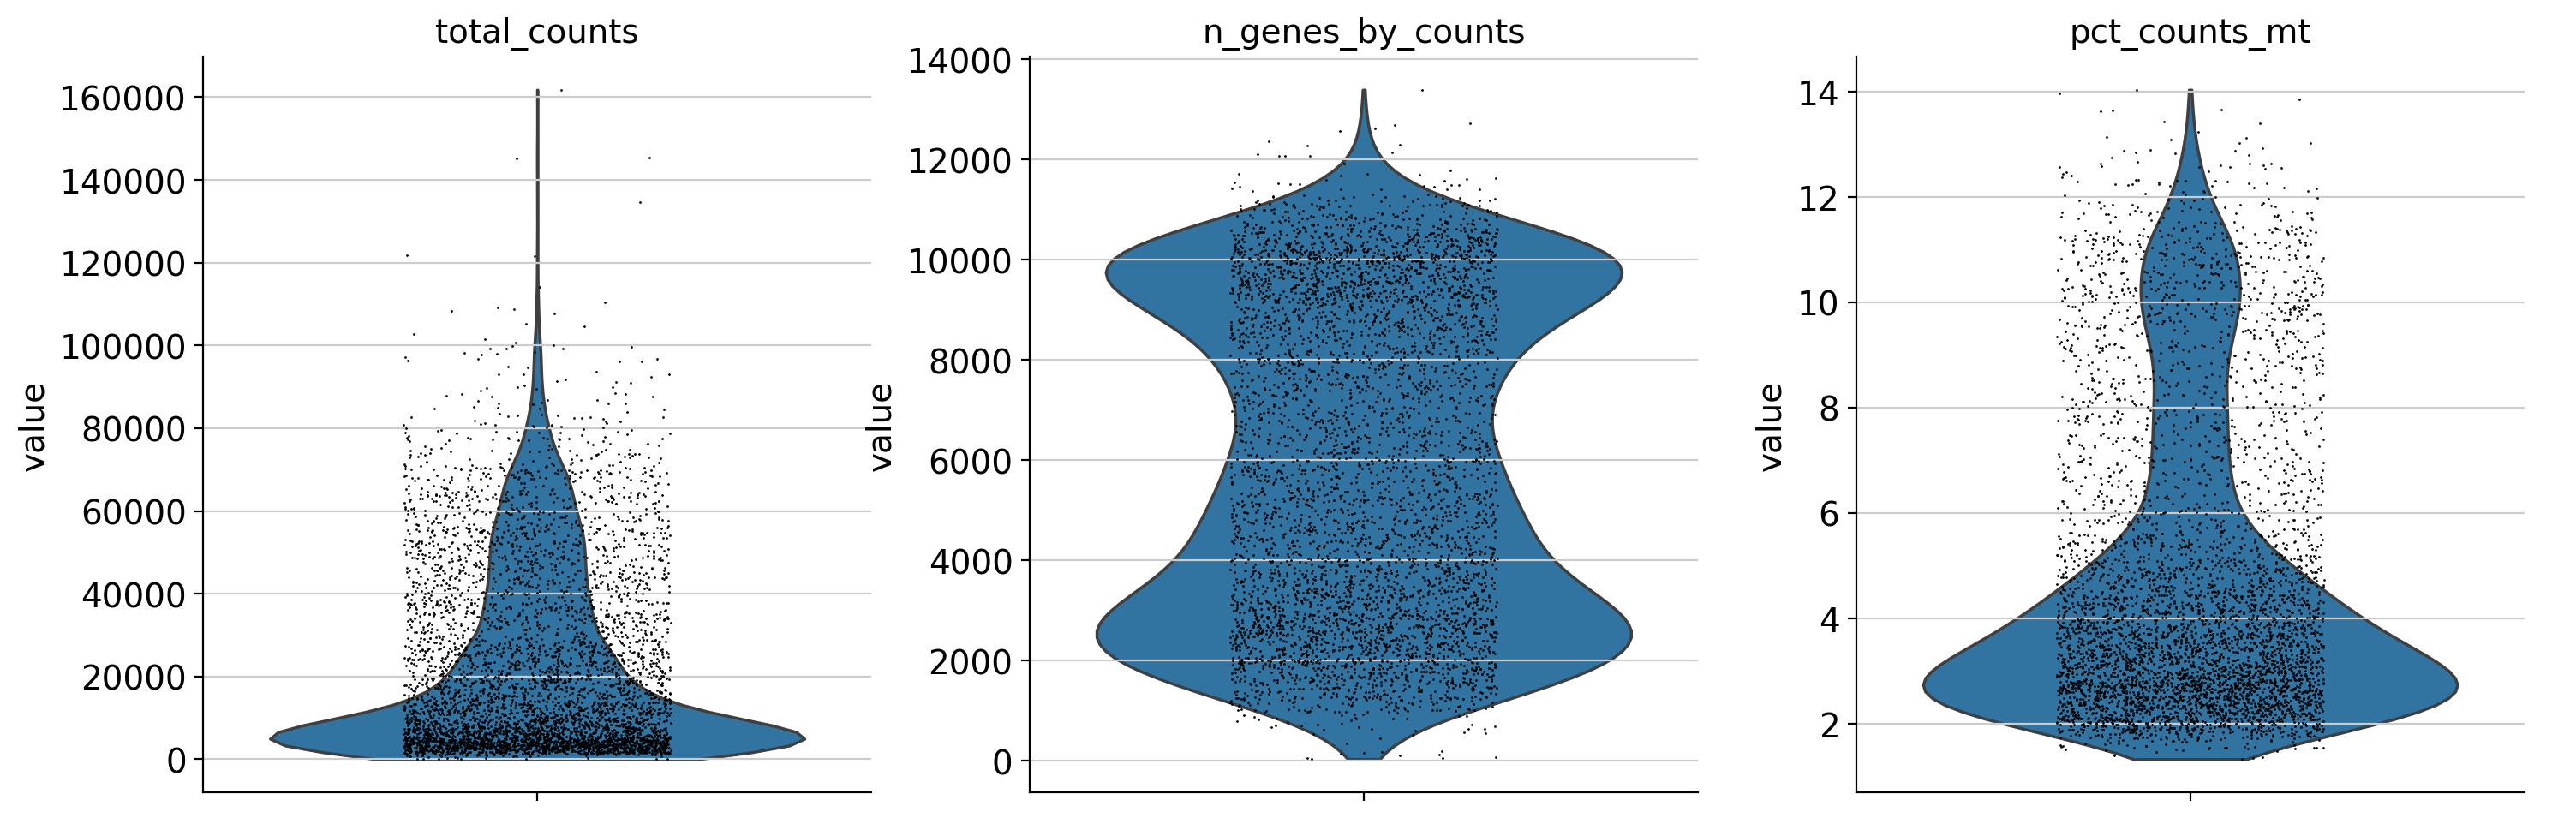

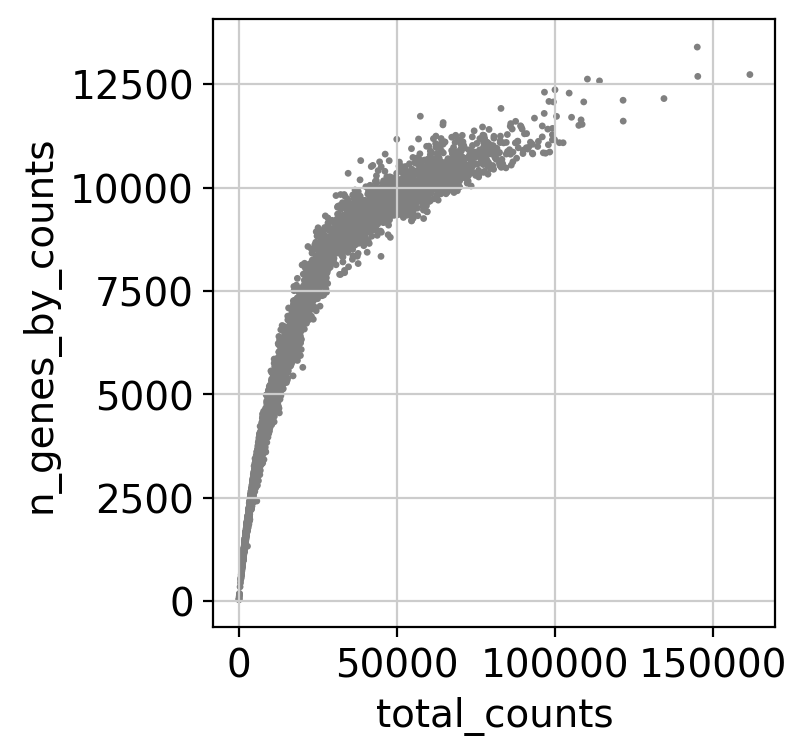

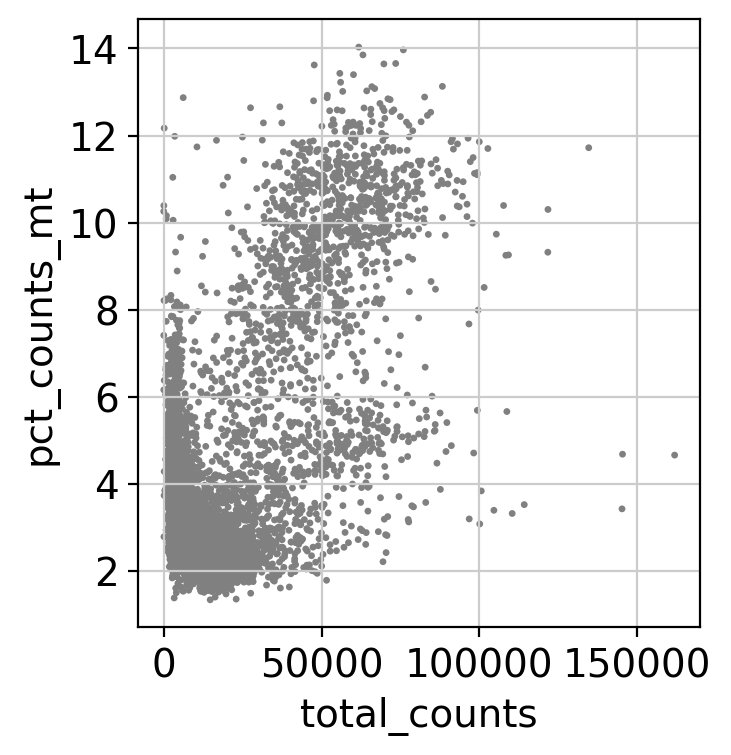

In [4]:
adata_vis.var["mt"] = adata_vis.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_vis, qc_vars=["mt"], percent_top=[20], log1p=False, inplace=True)

qc_cols = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
display(adata_vis.obs[qc_cols].describe().T)

sc.pl.violin(adata_vis, qc_cols, jitter=0.2, multi_panel=True)
sc.pl.scatter(adata_vis, x="total_counts", y="n_genes_by_counts")
sc.pl.scatter(adata_vis, x="total_counts", y="pct_counts_mt")

In [5]:
visium_qc_thresholds = {
    "min_genes": 200,
    "max_genes": 8000,
    "max_mito": 30.0,
}

keep_mask = (
    (adata_vis.obs["n_genes_by_counts"] >= visium_qc_thresholds["min_genes"])
    & (adata_vis.obs["n_genes_by_counts"] <= visium_qc_thresholds["max_genes"])
    & (adata_vis.obs["pct_counts_mt"] <= visium_qc_thresholds["max_mito"])
    & (adata_vis.obs["in_tissue"] == 1)
)

print("QC thresholds:", visium_qc_thresholds)
print(f"Spots before: {adata_vis.n_obs:,}")
print(f"Spots after:  {keep_mask.sum():,} ({keep_mask.mean():.1%})")

adata_vis_qc = adata_vis[keep_mask].copy()
print(adata_vis_qc)

QC thresholds: {'min_genes': 200, 'max_genes': 8000, 'max_mito': 30.0}
Spots before: 4,992
Spots after:  3,245 (65.0%)
AnnData object with n_obs × n_vars = 3245 × 18085
    obs: 'in_tissue', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'
    layers: 'counts'


## Normalize, cluster, and visualize

How Leiden works:

- Think of each spot as a node in a graph.
- Edges connect spots with similar expression profiles (nearest neighbors).
- Leiden partitions the graph into communities by maximizing within-group connectivity (modularity/CPM objective) while enforcing well-connected clusters.
- resolution controls granularity:
    - lower (e.g., 0.3) → fewer, larger clusters
    - higher (e.g., 1.0) → more, smaller clusters

normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes


/tmp/ipykernel_573320/1115722944.py:4: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_vis_work, flavor="seurat_v3", n_top_genes=3000)


computing PCA
    with n_comps=50


/home/katwre/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 30


/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:04)
computing UMAP
    finished (0:00:04)
running Leiden clustering


/tmp/ipykernel_573320/1115722944.py:10: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_vis_work, resolution=0.6)


    finished (0:00:00)


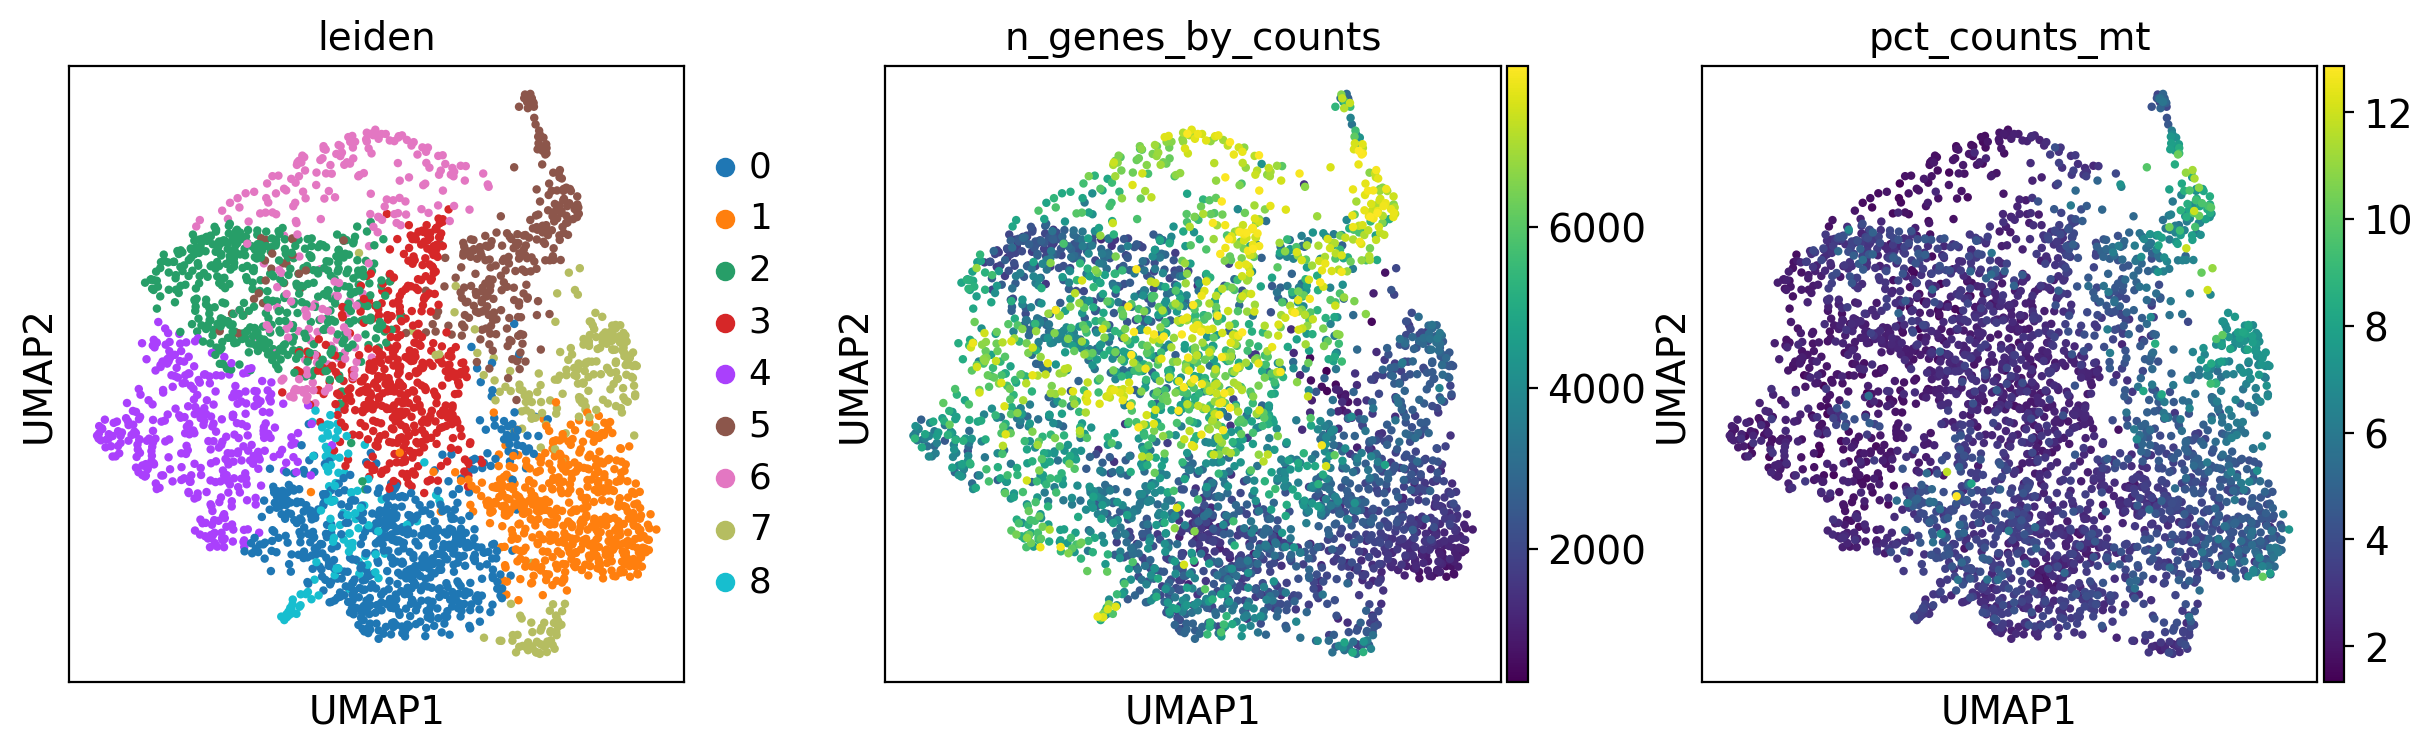

In [6]:
adata_vis_work = adata_vis_qc.copy()
sc.pp.normalize_total(adata_vis_work, target_sum=1e4)
sc.pp.log1p(adata_vis_work)
sc.pp.highly_variable_genes(adata_vis_work, flavor="seurat_v3", n_top_genes=3000)
adata_vis_work = adata_vis_work[:, adata_vis_work.var["highly_variable"]].copy()
sc.pp.scale(adata_vis_work, max_value=10)
sc.tl.pca(adata_vis_work, svd_solver="arpack")
sc.pp.neighbors(adata_vis_work, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_vis_work)
sc.tl.leiden(adata_vis_work, resolution=0.6)

sc.pl.umap(adata_vis_work, color=["leiden", "n_genes_by_counts", "pct_counts_mt"])

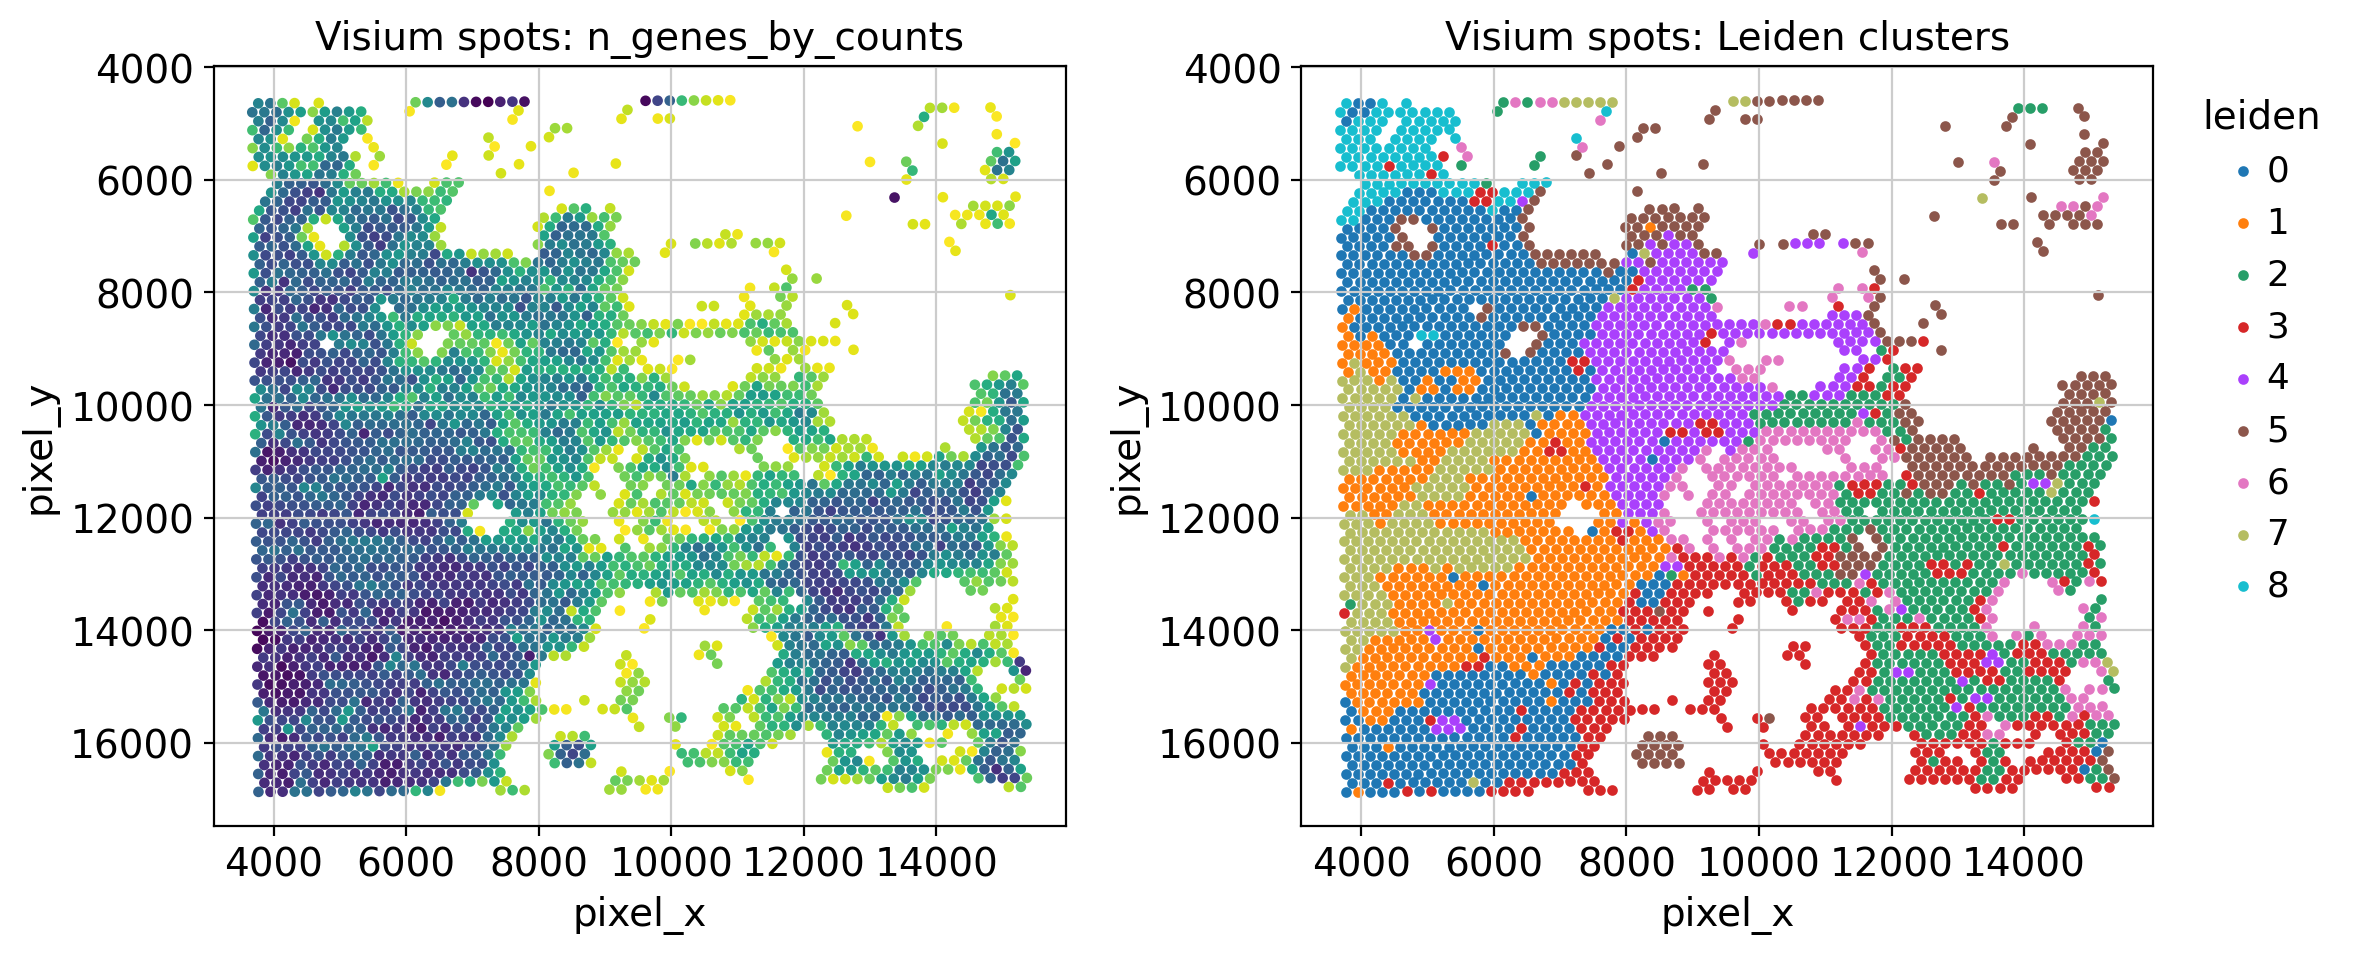

In [7]:
# Quick spatial-view scatter (uses tissue pixel coordinates)
spatial_xy = adata_vis_work.obsm["spatial"]
plot_df = pd.DataFrame({
    "x": spatial_xy[:, 0],
    "y": spatial_xy[:, 1],
    "leiden": adata_vis_work.obs["leiden"].astype(str).values,
    "n_genes": adata_vis_work.obs["n_genes_by_counts"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(plot_df["x"], plot_df["y"], c=plot_df["n_genes"], s=8, cmap="viridis")
axes[0].set_title("Visium spots: n_genes_by_counts")
axes[0].invert_yaxis()
axes[0].set_xlabel("pixel_x")
axes[0].set_ylabel("pixel_y")

for lab in sorted(plot_df["leiden"].unique()):
    m = plot_df["leiden"] == lab
    axes[1].scatter(plot_df.loc[m, "x"], plot_df.loc[m, "y"], s=8, label=lab)
axes[1].set_title("Visium spots: Leiden clusters")
axes[1].invert_yaxis()
axes[1].set_xlabel("pixel_x")
axes[1].set_ylabel("pixel_y")
axes[1].legend(title="leiden", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [8]:
visium_out_fp = OUT_DIR / "visium_qc_exploration.h5ad"
adata_vis_work.write_h5ad(visium_out_fp)
print(f"Saved: {visium_out_fp}")
print(adata_vis_work)

Saved: ../data/visium/visium_qc_exploration.h5ad
AnnData object with n_obs × n_vars = 3245 × 3000
    obs: 'in_tissue', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


In [ ]:
# Validation: barcode overlap between H5 matrix and tissue_positions.csv
h5_barcodes = pd.Index(adata_vis.obs_names)
tp_barcodes = pd.Index(tp["barcode"].astype(str)) if "barcode" in tp.columns else pd.Index(tp.iloc[:, 0].astype(str))

n_h5 = len(h5_barcodes)
n_tp = len(tp_barcodes)
n_overlap = h5_barcodes.isin(tp_barcodes).sum()
overlap_pct = (n_overlap / n_h5) * 100 if n_h5 > 0 else 0.0

print(f"H5 barcodes: {n_h5:,}")
print(f"tissue_positions barcodes: {n_tp:,}")
print(f"overlap: {n_overlap:,} ({overlap_pct:.2f}%)")

if overlap_pct < 90:
    print("Low barcode overlap: check sample pairing or barcode formatting.")
else:
    print("Barcode overlap looks consistent with a matched Visium sample.")

In [ ]:
# save adata_vis_qc (QC-filtered but not HVG-trimmed):

visium_map_fp = OUT_DIR / "visium_qc_for_cell2location.h5ad"
adata_vis_qc.write_h5ad(visium_map_fp)
print(visium_map_fp, adata_vis_qc.shape)